# 031 一维梯度下降与学习率

## Goal
用同一个已知答案的二次剖面，把方向、学习率、实际位移、收敛区间与停止原因分开。先逐行重算两轮，再比较真实float迭代、原始有理数理论与存储模型精确参照。所有数据是原创合成例子，不代表真实任务预测或大模型训练表现。

## Setup
从本讲目录打开，选择Python3内核，重启并顺序运行。先验证全部三份输入的完整字节，再产生数值或图；这保护固定手算例子。Anaconda安装、浏览器Jupyter与外部进程传输没有实际测试。

In [1]:
from pathlib import Path
import hashlib
ROOT = Path.cwd()
BASELINE_HASHES = {'data/regression.csv': 'fd25e5f2ff0267b59206ca3949fefcfa0a549d2e014c68c287c0eb70048f508b', 'data/learning_rates.csv': '9654c726de8fd505e554bd097ac436345e0531ac52d78cb7835d90222b5d87a4', 'data/model_spec.json': 'ad15b76616b42d5b0aef170fbf3aa4b56f72097b92987f71300b78a273575a48'}
for name, expected in BASELINE_HASHES.items():
    if hashlib.sha256((ROOT / name).read_bytes()).hexdigest() != expected:
        raise ValueError('This worked notebook requires the complete original inputs: ' + name)
import json
import math
from fractions import Fraction as F
import numpy as np
import matplotlib.pyplot as plt
import io
from IPython.display import Image, display
def show_figure(fig):
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", dpi=140, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))
    plt.close(fig)
import experiment as e
print('NumPy', np.__version__)


NumPy 2.3.5


## Steps
### 1 从数据独立恢复剖面
把每个斜率对应的最佳截距先消去。q=2、中心6/5、常数4/25；这里是单参数优化，不能混成固定截距或二维GD。

In [2]:
xs, ys = e.read_data()
rates = e.read_rates()
spec = e.read_spec()
report = e.compile_report(xs, ys, rates, spec)
model = report['profile']['model']
by_label = {item['label']: item for item in report['rates']}
print(report['profile']['exact'])
print('Stored 1.2:', F.from_float(1.2), 'original center:', F(6,5))
if report['profile']['exact']['center'] != '6/5':
    raise RuntimeError('Independent center mismatch')


{'q': '2', 'center': '6/5', 'constant': '4/25', 'intercept': '3/5', 'x_mean': '2', 'y_mean': '3'}
Stored 1.2: 5404319552844595/4503599627370496 original center: 6/5


### 2 两轮更新 完整保留每一行
每行链式法则：损失对残差导数r/n，残差对预测导数1，预测对b导数x−2。五行都依赖共享b，梯度贡献必须求和。更新后重新前向。

In [3]:
b = F(0)
for t in range(3):
    rows = []
    for x, y in zip(xs, ys):
        fx, fy = F.from_float(x), F.from_float(y)
        prediction = 3 + b * (fx - 2)
        residual = prediction - fy
        local_derivative = fx - 2
        contribution = residual * local_derivative / 5
        rows.append((prediction, residual, residual**2, local_derivative, contribution))
    loss = sum(row[2] for row in rows) / 10
    gradient = sum(row[4] for row in rows)
    print('t=', t, 'b=', str(b), 'a=', str(3-2*b))
    print('prediction | residual | square | local derivative | gradient contribution')
    for row in rows:
        print(' | '.join(map(str, row)))
    print('loss=', str(loss), 'gradient=', str(gradient))
    if loss != [F(8,5), F(13,25), F(1,4)][t]:
        raise RuntimeError('Paper forward pass mismatch')
    b -= F(1,4) * gradient


t= 0 b= 0 a= 3
prediction | residual | square | local derivative | gradient contribution
3 | 2 | 4 | -2 | -4/5
3 | 1 | 1 | -1 | -1/5
3 | 1 | 1 | 0 | 0
3 | -1 | 1 | 1 | -1/5
3 | -3 | 9 | 2 | -6/5
loss= 8/5 gradient= -12/5
t= 1 b= 3/5 a= 9/5
prediction | residual | square | local derivative | gradient contribution
9/5 | 4/5 | 16/25 | -2 | -8/25
12/5 | 2/5 | 4/25 | -1 | -2/25
3 | 1 | 1 | 0 | 0
18/5 | -2/5 | 4/25 | 1 | -2/25
21/5 | -9/5 | 81/25 | 2 | -18/25
loss= 13/25 gradient= -6/5
t= 2 b= 9/10 a= 6/5
prediction | residual | square | local derivative | gradient contribution
6/5 | 1/5 | 1/25 | -2 | -2/25
21/10 | 1/10 | 1/100 | -1 | -1/50
3 | 1 | 1 | 0 | 0
39/10 | -1/10 | 1/100 | 1 | -1/50
24/5 | -6/5 | 36/25 | 2 | -12/25
loss= 1/4 gradient= -3/5


### 3 七种学习率的参数轨迹
同一个模型和初值，改变η。固定模式保留20次实际更新；显示真实完成数和最终状态，不把固定预算完成误写成收敛。

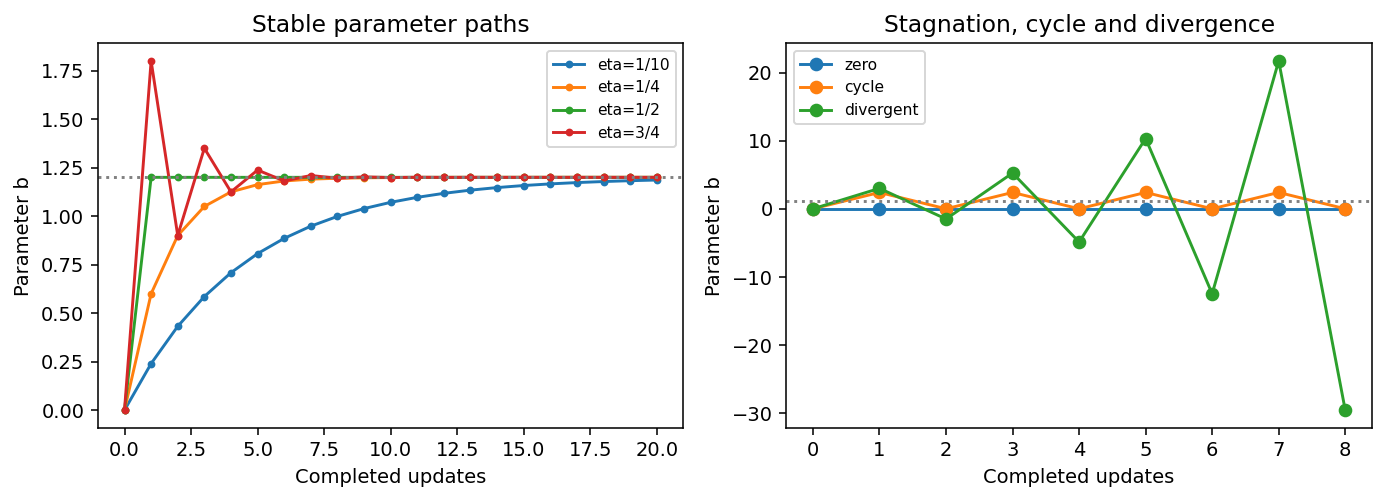

zero 1 fixed_budget_completed 20
slow 4/5 fixed_budget_completed 20
monotone 1/2 fixed_budget_completed 20
one_step 0 fixed_budget_completed 20
oscillating -1/2 fixed_budget_completed 20
cycle -1 fixed_budget_completed 20
divergent -3/2 fixed_budget_completed 20


In [4]:
fig, axs = plt.subplots(1, 2, figsize=(10, 3.7))
for label in ['slow', 'monotone', 'one_step', 'oscillating']:
    item = by_label[label]
    h = item['fixed']['history']
    axs[0].plot([r['t'] for r in h], [r['w'] for r in h], '-o', ms=3, label='eta='+item['exact_eta'])
for label in ['zero', 'cycle', 'divergent']:
    item=by_label[label]; h=item['fixed']['history'][:9]
    axs[1].plot([r['t'] for r in h], [r['w'] for r in h], '-o', label=label)
for ax in axs:
    ax.axhline(model['center'], color='gray', linestyle=':')
    ax.set(xlabel='Completed updates', ylabel='Parameter b')
    ax.legend(fontsize=8)
axs[0].set_title('Stable parameter paths'); axs[1].set_title('Stagnation, cycle and divergence')
fig.tight_layout(); show_figure(fig)
for item in report['rates']:
    print(item['label'], item['rho_exact'], item['fixed']['status'], item['fixed']['updates_completed'])


### 4 参数交替与损失下降不矛盾
η=1/4和3/4的精确ρ是1/2和−1/2。精确目标超额相同，但实际float后期可能有舍入区别。图的0值只为显示放在1e-18下限；原JSON不改写。

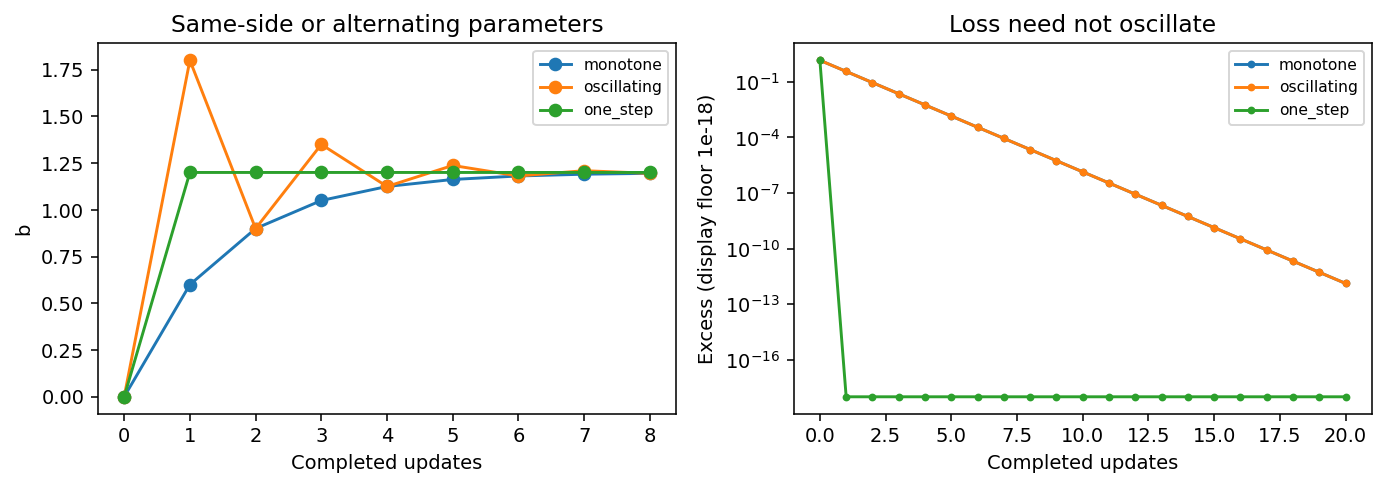

All exact excess values equal: True


In [5]:
fig, axs = plt.subplots(1,2,figsize=(10,3.6))
for label in ['monotone','oscillating','one_step']:
    item=by_label[label];h=item['fixed']['history']
    axs[0].plot([r['t'] for r in h[:9]],[r['w'] for r in h[:9]],'-o',label=label)
    axs[1].semilogy([r['t'] for r in h],[max(r['excess_direct'],1e-18) for r in h],'-o',ms=3,label=label)
axs[0].set(xlabel='Completed updates',ylabel='b',title='Same-side or alternating parameters')
axs[1].set(xlabel='Completed updates',ylabel='Excess (display floor 1e-18)',title='Loss need not oscillate')
for ax in axs:ax.legend(fontsize=8)
fig.tight_layout();show_figure(fig)
a=[r['excess'] for r in by_label['monotone']['rational_theory']]
b=[r['excess'] for r in by_label['oscillating']['rational_theory']]
if a != b:raise RuntimeError('Exact loss equivalence failed')
print('All exact excess values equal:',a==b)


### 5 三种参照与单步恒等式
先比较精确数学模型和存储系数模型，再检查实际更新。后者不能用闭式结果替代。这里只展示前六轮，完整参照均保存在report中。

In [6]:
item=by_label['monotone']
for actual, theory, stored in zip(item['fixed']['history'][:6], item['rational_theory'][:6], item['stored_model_exact_arithmetic'][:6]):
    print(actual['t'], 'float=', format(actual['w'],'.17g'), 'rational=',theory['w'], 'stored-exact=',stored['w'])
for eta in [F(0),F(1,4),F(1,2),F(3,4),F(1),F(5,4)]:
    w=F(0);q=F(2);center=F(6,5);constant=F(4,25);g=q*(w-center)
    change=q/2*((w-eta*g-center)**2-(w-center)**2)
    predicted=-eta*(1-eta*q/2)*g*g
    if change!=predicted:raise RuntimeError('Exact one-step identity failed')
    print('eta',eta,'exact objective change',change)


0 float= 0 rational= 0 stored-exact= 0
1 float= 0.59999999999999998 rational= 3/5 stored-exact= 5404319552844595/9007199254740992
2 float= 0.89999999999999991 rational= 9/10 stored-exact= 16212958658533785/18014398509481984
3 float= 1.0499999999999998 rational= 21/20 stored-exact= 37830236869912165/36028797018963968
4 float= 1.125 rational= 9/8 stored-exact= 81064793292668925/72057594037927936
5 float= 1.1625000000000001 rational= 93/80 stored-exact= 167533906138182445/144115188075855872
eta 0 exact objective change 0
eta 1/4 exact objective change -27/25
eta 1/2 exact objective change -36/25
eta 3/4 exact objective change -27/25
eta 1 exact objective change 0
eta 5/4 exact objective change 9/5


### 6 目标乘常数 记得补偿步长
目标乘10，原参数路径匹配所需学习率除10。把J变成SSE却漏掉补偿，会把ρ=.5变成−4。这里画参数绝对误差，让发散尺度也能看清。

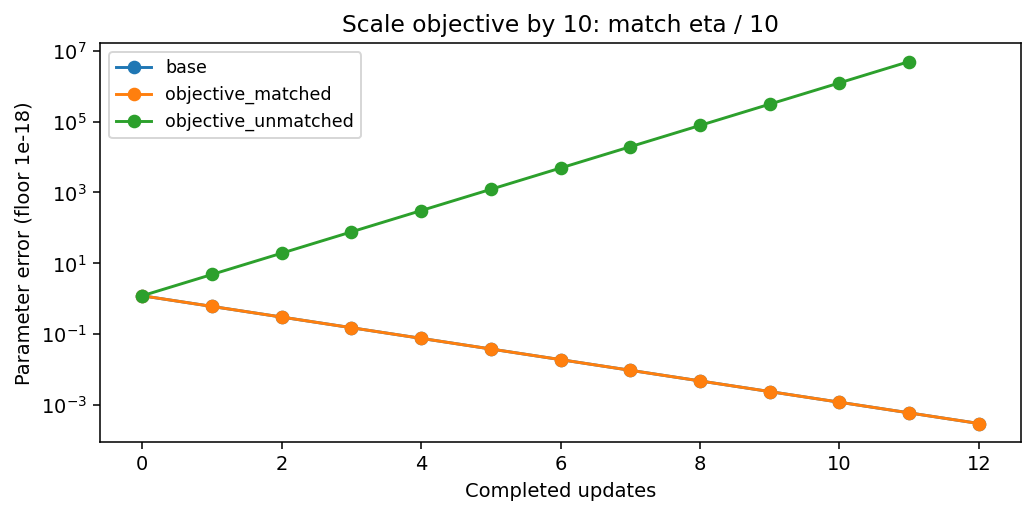

In [7]:
fig,ax=plt.subplots(figsize=(7.5,3.8))
for key in ['base','objective_matched','objective_unmatched']:
    h=report['scaling'][key]['history']
    ax.semilogy([r['t'] for r in h],[max(abs(r['w']-model['center']),1e-18) for r in h],'-o',label=key)
ax.set(xlabel='Completed updates',ylabel='Parameter error (floor 1e-18)',title='Scale objective by 10: match eta / 10')
ax.legend(fontsize=9);fig.tight_layout();show_figure(fig)


### 7 参数坐标乘100 需要另一种补偿
v=100w的梯度多除一个100，映回原坐标再除100，故η_v=10000η_w=2500。下面先映回原单位再比较。

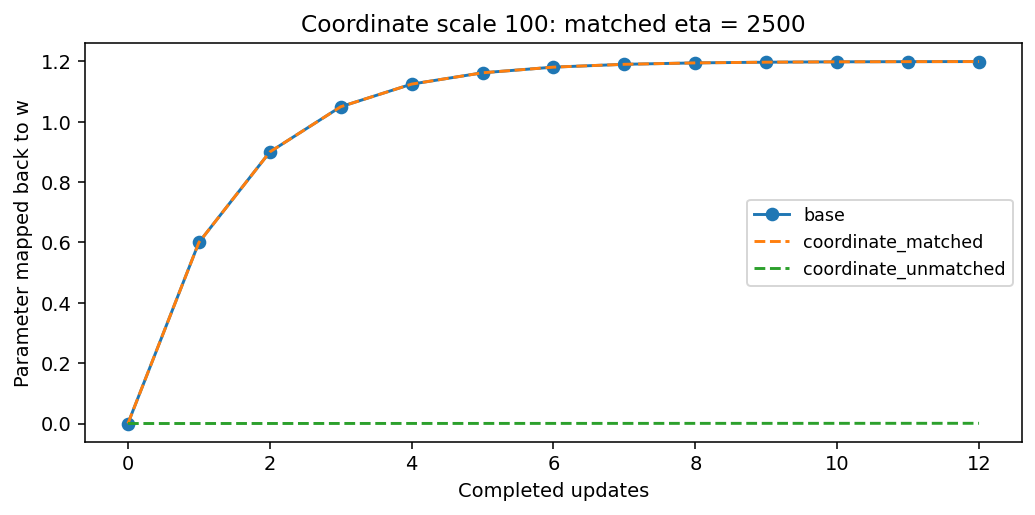

Matched coordinate eta: 2500.0


In [8]:
fig,ax=plt.subplots(figsize=(7.5,3.8))
for key in ['base','coordinate_matched','coordinate_unmatched']:
    h=report['scaling'][key]['history'];scale=100 if key!='base' else 1
    ax.plot([r['t'] for r in h],[r['w']/scale for r in h],'-o' if key=='base' else '--',label=key)
ax.set(xlabel='Completed updates',ylabel='Parameter mapped back to w',title='Coordinate scale 100: matched eta = 2500')
ax.legend(fontsize=9);fig.tight_layout();show_figure(fig)
print('Matched coordinate eta:',report['scaling']['matched_coordinate_rate'])


### 8 首次达到阈值 必须检查前一轮
原始十进制分数阈值与配置float阈值在本例给出相同轮数。分别检验21/20和35/34，不能只检查满足的那轮。

Configured exact-binary thresholds: {'parameter': 21, 'gradient': 35}
first t= 21 current= 5.7220458984375e-07 previous= 1.1444091796875e-06
first t= 35 current= 6.984919309616089e-11 previous= 1.3969838619232177e-10


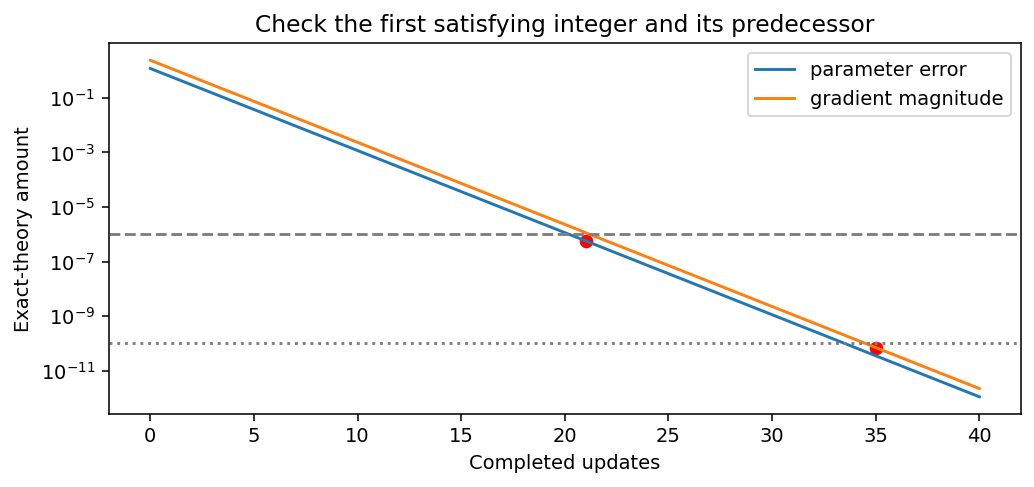

In [9]:
print('Configured exact-binary thresholds:',report['exact_thresholds'])
for t, threshold, multiplier in [(21,F(1,10**6),1),(35,F(1,10**10),2)]:
    current=multiplier*F(6,5)*F(1,2)**t
    previous=multiplier*F(6,5)*F(1,2)**(t-1)
    if not current<=threshold<previous:raise RuntimeError('First crossing is incorrect')
    print('first t=',t,'current=',float(current),'previous=',float(previous))
fig,ax=plt.subplots(figsize=(7.5,3.6));t=np.arange(41)
ax.semilogy(t,1.2*.5**t,label='parameter error');ax.semilogy(t,2.4*.5**t,label='gradient magnitude')
ax.axhline(1e-6,ls='--',color='gray');ax.axhline(1e-10,ls=':',color='gray')
ax.scatter([21,35],[1.2*.5**21,2.4*.5**35],color='red')
ax.set(xlabel='Completed updates',ylabel='Exact-theory amount',title='Check the first satisfying integer and its predecessor')
ax.legend();fig.tight_layout();show_figure(fig)


### 9 停止状态与浮点相邻值
参数不变不代表零梯度；f−c=0也不代表直接超额为0。停滞示例使用实际存储中心的相邻float，不把它与数学6/5混淆。

zero stagnation 0 -2.4
slow gradient_tolerance 108 -8.202194479167702e-11
monotone gradient_tolerance 35 -6.98494595496868e-11
one_step exact_stored_optimum 1 0.0
oscillating gradient_tolerance 35 6.98494595496868e-11
cycle two_cycle 2 -2.4
divergent growth_guard 39 17691731.713504024
Adjacent stored value diagnostics: {'t': 0, 'w': 1.2000000000000002, 'error': 2.220446049250313e-16, 'gradient': 4.440892098500626e-16, 'objective': 0.16, 'excess_direct': 4.930380657631324e-32, 'excess_subtracted': 0.0, 'step_from_previous': 0.0}
Tiny-rate status: stagnation


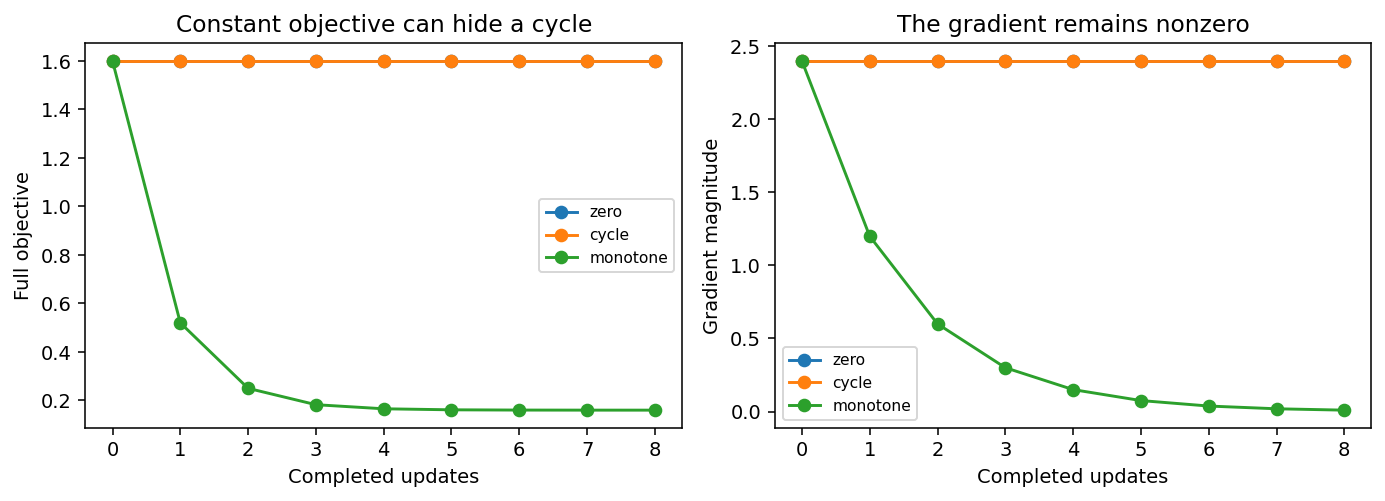

In [10]:
for item in report['rates']:
    p=item['stopping'];print(item['label'],p['status'],p['updates_completed'],p['final']['gradient'])
print('Adjacent stored value diagnostics:',report['cancellation_example'])
print('Tiny-rate status:',report['stagnation_example']['status'])
fig,axs=plt.subplots(1,2,figsize=(10,3.7))
for label in ['zero','cycle','monotone']:
    h=by_label[label]['fixed']['history'][:9]
    axs[0].plot([r['t'] for r in h],[r['objective'] for r in h],'-o',label=label)
    axs[1].plot([r['t'] for r in h],[abs(r['gradient']) for r in h],'-o',label=label)
axs[0].set(xlabel='Completed updates',ylabel='Full objective',title='Constant objective can hide a cycle')
axs[1].set(xlabel='Completed updates',ylabel='Gradient magnitude',title='The gradient remains nonzero')
for ax in axs:ax.legend(fontsize=8)
fig.tight_layout();show_figure(fig)


### 10 超出二次函数的反例
w⁴从1以η=1走到−3，损失1变81；另外两个函数的零导数不是最小点。它们界定理论条件，不能当成二次定理的反证。

{'initial': 1.0, 'gradient': 4.0, 'next': -3.0, 'loss_before': 1.0, 'loss_after': 81.0}


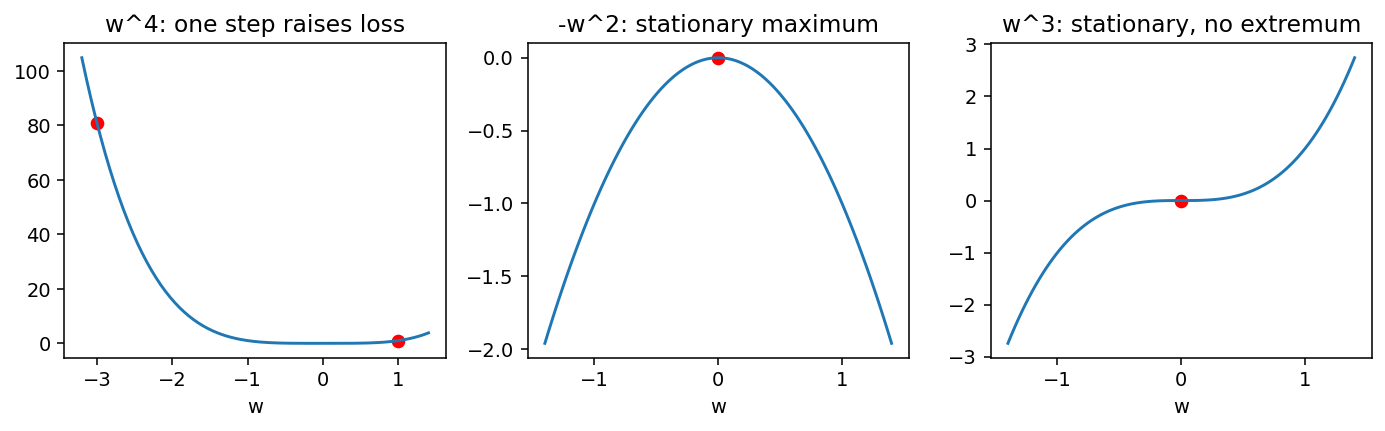

In [11]:
print(report['quartic_counterexample'])
fig,axs=plt.subplots(1,3,figsize=(10,3.2));z=np.linspace(-3.2,1.4,150)
axs[0].plot(z,z**4);axs[0].scatter([1,-3],[1,81],color='red');axs[0].set_title('w^4: one step raises loss')
z=np.linspace(-1.4,1.4,100)
axs[1].plot(z,-z*z);axs[1].scatter([0],[0],color='red');axs[1].set_title('-w^2: stationary maximum')
axs[2].plot(z,z**3);axs[2].scatter([0],[0],color='red');axs[2].set_title('w^3: stationary, no extremum')
for ax in axs:ax.set_xlabel('w')
fig.tight_layout();show_figure(fig)


## Checks
### 11 失败输入保护旧报告
故意损坏最后一条学习率和JSON末字段。失败应发生在输出替换前；这里仅列示例，完整有限审计范围见verification.json。

In [12]:
import tempfile
import copy
for changed in [dict(spec,max_steps=True),dict(spec,counterexample_rate='1')]:
    try:e.compile_report(xs,ys,rates,changed)
    except ValueError as exc:print('Rejected config:',str(exc))
    else:raise RuntimeError('Invalid configuration accepted')
with tempfile.TemporaryDirectory() as directory:
    temp=Path(directory);old=temp/'old.json';old.write_bytes(b'SENTINEL')
    invalid=temp/'rates.csv'
    invalid.write_text((ROOT/'data/learning_rates.csv').read_text().replace('divergent,5,4','divergent,5,0'))
    try:e.run(rates=invalid,output=old)
    except ValueError:pass
    else:raise RuntimeError('Invalid trailing rate accepted')
    if old.read_bytes()!=b'SENTINEL':raise RuntimeError('Old report was changed')
print('Failure output protection passed')
encoded=json.dumps(report,ensure_ascii=False,indent=2,allow_nan=False)+'\n'
print('Complete report SHA256:',hashlib.sha256(encoded.encode()).hexdigest())


Rejected config: max_steps must be bounded integer
Rejected config: counterexample_rate must be an ordinary real scalar
Failure output protection passed
Complete report SHA256: 3e6be74e829b7168b8625f17041b2cb5c4dd0087ca5ea07828d80026506e2786


## Next Steps
本例精确收敛区间是0<ηq<2，初值已最优是例外。参数误差与损失超额有不同倍率；目标和坐标缩放需要不同步长补偿。停止状态只说明检测到的条件。下一讲把ρ推广成多个Hessian特征方向上的倍率，解释之字形轨迹与条件数。